In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [2]:
df=pd.read_csv(r"C:\Users\cfl602\Downloads\CarPrice_Assignment.csv")

In [3]:
df.shape

(205, 26)

In [4]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [5]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [6]:
num_col=df.select_dtypes(exclude='object')

In [7]:
num_col.columns

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [8]:
colsDrp=['symboling','carheight','stroke','compressionratio','peakrpm','CarName']
df.drop(columns=colsDrp,axis=1,inplace=True)

In [9]:
cat_col=df.select_dtypes(include=['object']).columns
df[cat_col].nunique()

fueltype          2
aspiration        2
doornumber        2
carbody           5
drivewheel        3
enginelocation    2
enginetype        7
cylindernumber    7
fuelsystem        8
dtype: int64

In [10]:
df = pd.get_dummies(columns = ['fueltype', 'aspiration', 'doornumber', 'drivewheel', 'enginelocation'], data = df, drop_first = True)

In [11]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [12]:
encoder=OrdinalEncoder()
for i in df.select_dtypes(include='object').columns:
    df[i]=encoder.fit_transform(df[[i]])

In [13]:
X=df.drop('price',axis=1) #feature columns
y=df['price'] #Label column

In [14]:
X.shape

(205, 20)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=20)

In [17]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LinearRegression, Ridge

In [19]:
#Multiple linear regression

In [20]:
rgsr=LinearRegression()

In [21]:
model=rgsr.fit(X_train_scaled,y_train)

In [22]:
y_pred=model.predict(X_test_scaled)

In [23]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [25]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MLR (All features)")
print(f"Mean absolute error={mae:.2f}")
print(f"Root mean squared error={rmse:.2f}")
print(f"R squared score:{r2*100:.2f}%\n")

MLR (All features)
Mean absolute error=1970.16
Root mean squared error=2421.17
R squared score:83.18%



In [26]:
#visualisation

In [27]:
pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
#initialise visualisation model and import
from yellowbrick.regressor import PredictionError

In [33]:
#Model 1
visualizer=PredictionError(rgsr)

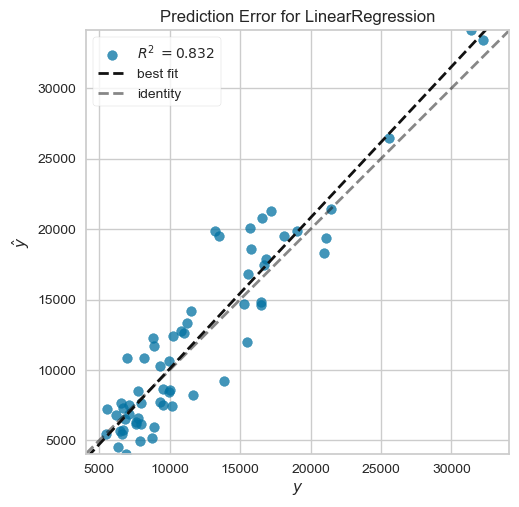

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [32]:
#fit the training data to visualiser
visualizer.fit(X_train_scaled,y_train)

#evaluate model on test data
visualizer.score(X_test_scaled,y_test)

#finalize and render figure
visualizer.show()

In [34]:
#model 2-Feature selection (SFS)

In [35]:
rgsr=LinearRegression()

In [36]:
from sklearn.feature_selection import SequentialFeatureSelector as sfs

In [37]:
selector=sfs(rgsr,n_features_to_select=5,direction='backward')
selector=selector.fit(X_train_scaled,y_train)

#get the names
selected_features=list(X.columns[selector.get_support()] )
print(selected_features)

#slice the orignal data frame
X_train_selected=X_train[selected_features]
X_test_selected=X_test[selected_features]

#Re scale
scaler_new=StandardScaler()
X_train_sel_scaled=scaler_new.fit_transform(X_train_selected)
X_test_sel_scaled=scaler_new.transform(X_test_selected)

#Fit the model
model=rgsr.fit(X_train_sel_scaled,y_train)

['car_ID', 'wheelbase', 'enginesize', 'horsepower', 'enginelocation_rear']


In [38]:
y_pred_sfs=model.predict(X_test_sel_scaled)

In [39]:
mae_sfs=mean_absolute_error(y_test,y_pred_sfs)
mse_sfs=mean_squared_error(y_test,y_pred_sfs)
rmse_sfs=np.sqrt(mse_sfs)
r2_sfs=r2_score(y_test,y_pred_sfs)

print("MLR (SFS selected features)")
print(f"Selected features: {list(X.columns[selector.get_support()])}")
print(f"Mean absolute error={mae:.2f}")
print(f"Root mean squared error={rmse:.2f}")
print(f"R squared score:{r2*100:.2f}%\n")

MLR (SFS selected features)
Selected features: ['car_ID', 'wheelbase', 'enginesize', 'horsepower', 'enginelocation_rear']
Mean absolute error=1970.16
Root mean squared error=2421.17
R squared score:83.18%

